# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle non-linear relationships, mainly in the context of classification and regression tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how PCA can help with this, but as we discussed this week, (ordinary) PCA is a linear method and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are typically used for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: Palmer Penguins
- A high-dimensional human genotype dataset from the 1000 Genomes Project (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


NAME(s) = "Kaitlin Luu, Natalie Schweickert, James Torgerson"

## 1. Background Reading (20 points)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.

We would choose t-SNE or UMAP over PCA for dimensionality reduction if the relationships in the data are non-linear. In high-dimensionality data, there are complex or underlying relationships, such as clusters or curves in the data. PCA could miss these patterns since it simplifies the data, which would result in less accurate predictions and a higher MSE. In particular, t-SNE is able to preserve local structure, while UMAP preserves both the global and local structure. 


b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?


YOUR TEXT HERE


c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.

**t-SNE:**
- `perplexity`: This describes the effective number of neighbors considered for each point, which affects the balance between preserving global vs. local structure in our visualization. Smaller perplexity values emphasize local relationships, whereas larger perplexity values emphasize global relationships/broader trends. Perplexity values must be less than the number of samples.

**UMAP:**
- `n_neighbors`: This determines the size of the local neighborhood (or, how many points can be considered neighbors) for each point. Smaller n values emphasize local relationships whereas larger values emphasize global relationships.
- `min_dist`: This describes the minimum distance between points, which affects how tightly UMAP can pack points together in reduced space. Smaller minimum distances result in more compact clusters (emphasizing local trends), and larger minimum distances result in more spread out clusters (emphasizing global trends).

## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: Palmer Penguins.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the Palmer Penguins dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
penguins = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")
print(penguins.head())

#standardize the 4 feautres 
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins[features] = StandardScaler().fit_transform(penguins[features])
# print mean to make sure standardized correctly 
print(penguins[features].mean().round(4))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  
bill_length_mm       0.0
bill_depth_mm        0.0
flipper_length_mm   -0.0
body_mass_g          0.0
dtype: float64


b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

*N.B.* You may need to first install `UMAP-learn`. Follow the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html) for that.

C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


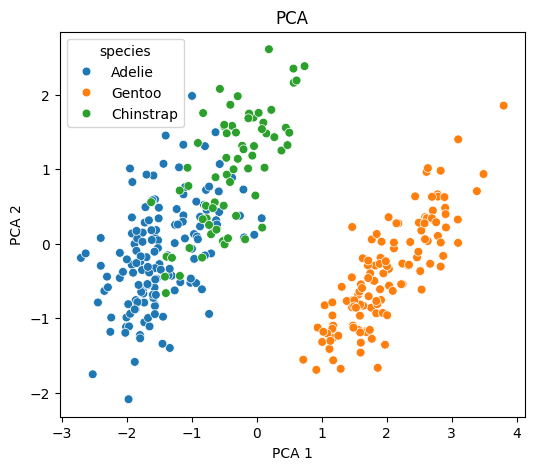

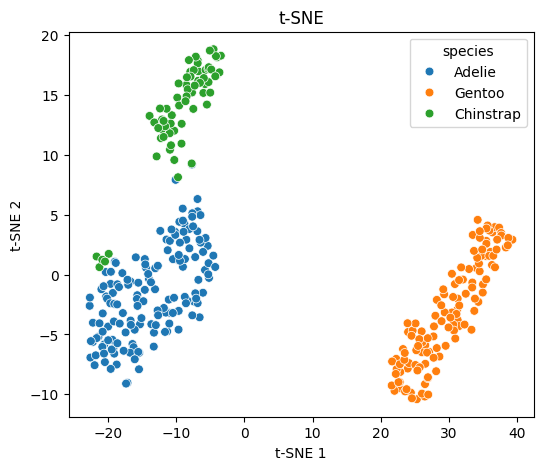

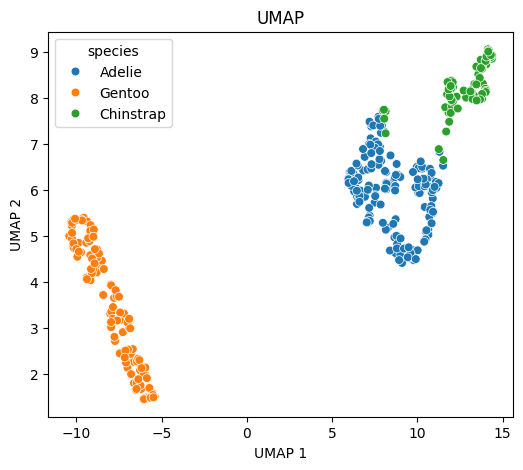

In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import umap

# drop NA / missing values becuase cannot plot 
penguins = penguins.dropna(subset=features).reset_index(drop=True)

#make dataset X
X = penguins[features]


# PCA projection with 2 components 
pca_2d = PCA(n_components=2).fit_transform(X)
# t-SNE projection with 2 components 
tsne_2d = TSNE(n_components=2, random_state=42).fit_transform(X)
# UMAP projection with 2 components 
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

projections = {"PCA": pca_2d, "t-SNE": tsne_2d, "UMAP": umap_2d}

# for loop for projections 
for name, i in projections.items():
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        x=i[:, 0], y=i[:, 1],
        hue=penguins['species'], s=40
    )
    plt.title(name)
    plt.xlabel(f"{name} 1")
    plt.ylabel(f"{name} 2")
    plt.show()

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


For PCA, Adelie and Chinstrap seem to be clustered together on the left side with points overlapping, while Gentoo is clearly by itself on the right side. For t-SNE, there is more separation between Adelie and Chinstrap on the left side, with Gentoo by itself on the right side again. For UMAP Gentoo is by itself on the left side with Adelie and Chinstrap mostly separated on the right side. We believe that t-SNE produced more visually separated clusters. In all 3 models Adelie (blue) and Chinstrap (green) overlap. However, they overlap heavily in PCA and then barely in t-SNE and UMAP. These differences in how the data is projected can be explained because PCA is linear and t-SNE and UMAP are non-linear. For PCA, a strength is that is is fast and the axes are combinations of the feautres, but a weakness is that it cannot capture nonlinear data well. t-SNE is good at revealing local clusters, but the distances between clusters and cluster sizes are not meaningful. For UMAP, it has similar cluster separation to t-SNE and i susually faster and keeps more global structure, but it is sensitive to hyperparameters .

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.
- Keep `random_state` fixed across all runs so that differences between projections are due primarily to changes in the hyperparameters rather than random initialization.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

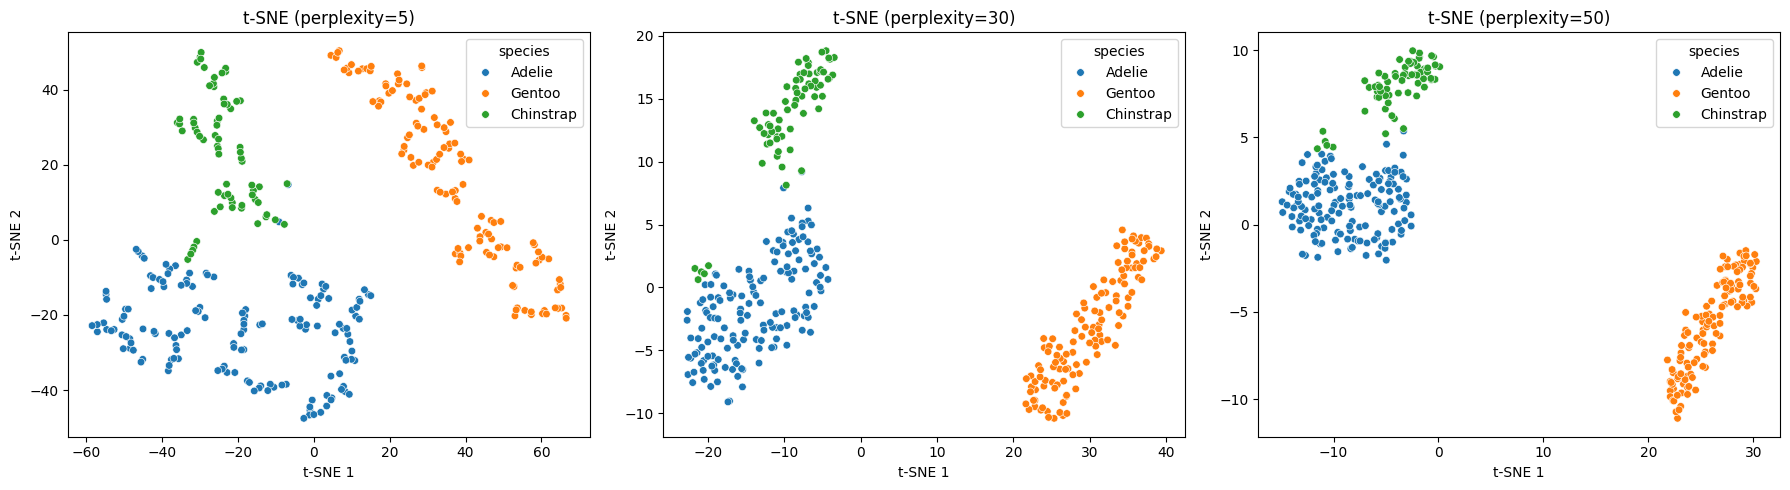

C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\kaitl\AppData\Roaming\Python\Python311\site-package

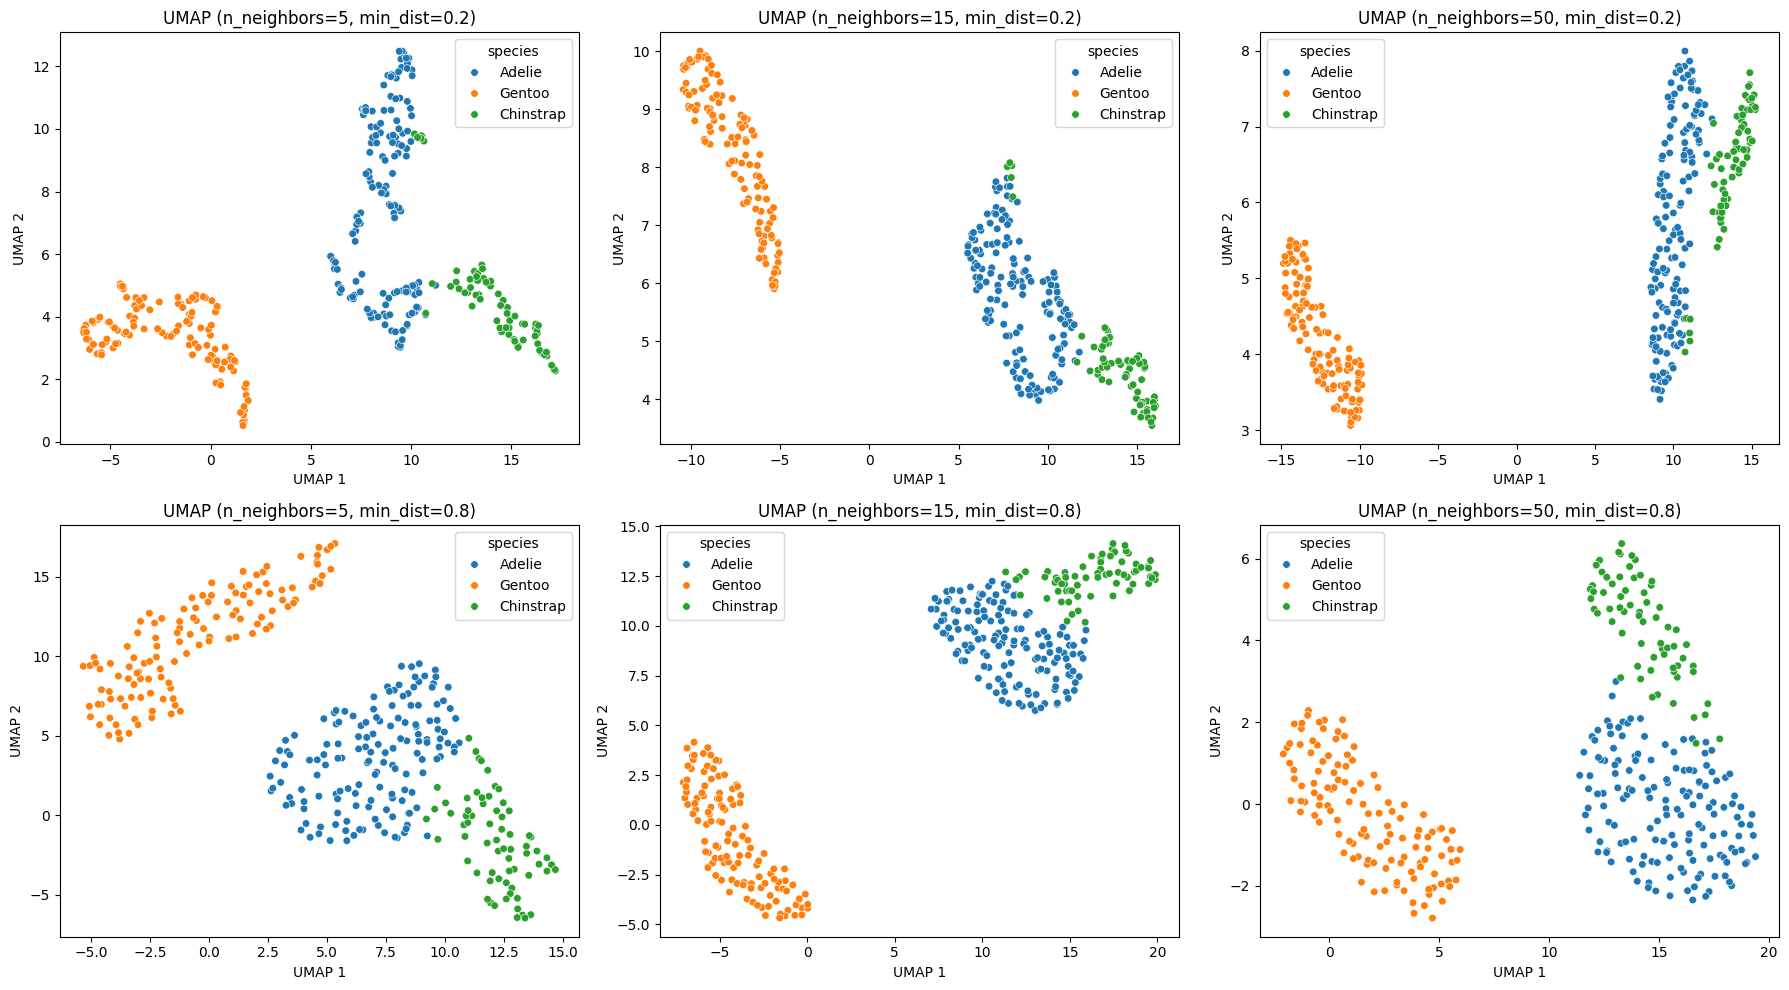

In [12]:
# t-SNE with varied perplexities
perplexities = [5, 30, 50]

# make plots for each perplexity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# reduce data to 2 dimensions and plot the 2D embedding
for ax, p in zip(axes, perplexities):
    emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(X)
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=penguins['species'], s=30, ax=ax)
    ax.set_title(f"t-SNE (perplexity={p})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# UMAP with varied n_neighbors and min_dist
n_neighbors_list = [5, 15, 50]
min_dists = [0.2, 0.8]

# make plots for each combination of parameters
fig, axes = plt.subplots(len(min_dists), len(n_neighbors_list), figsize=(18, 10))

# reduce data to 2 dimensions and plot the 2D embedding
for r, md_ in enumerate(min_dists):
    for c, nn in enumerate(n_neighbors_list):
        emb = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md_, random_state=42).fit_transform(X)
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=penguins['species'], s=30, ax=axes[r, c])
        axes[r, c].set_title(f"UMAP (n_neighbors={nn}, min_dist={md_})")
        axes[r, c].set_xlabel("UMAP 1")
        axes[r, c].set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

- For t-SNE, as the perplexity increases, the clusters become more visually separable and Gentoo shifts farther away from Adelie and Chinstrap. With a perplexity of 5, each species is stretched into many small clusters and strands. They are separated somewhat from each other, but are not fully distinguishable groups. A perplexity of 30 creates more distinct clusters, with Gentoo being clearly separated from Adelie and Chinstrap, which have a bit of overlap. A perplexity of 50 produces the most distinct and tightly packed groups, with Adelie and Chinstrap having slightly less overlap. For UMAP, when min_dist=0.2, as n_neighbors increases, the clusters become more visually separable and Gentoo shifts farther away from Adelie and Chinstrap. However, when min_dist=0.8, the clusters are the most visually separable in the middle range with 15 n_neighbors. For both min_dist values, 5 n_neighbors creates small, fragmented clusters and strands. Across all n_neighbors values, min_dist=0.2 produces thinner, stretched out clusters and has some overlap between Adelie and Chinstrap. On the other hand, min_dist=0.8 produces rounder, more distinguishable clusters and has less overlap.  

- The settings that best preserve the structure of the data appear to be values in the high or middle range. Perplexities of 30 and 50, as well as n_neighbors of 15 and 50 created the most visually separable clusters. Additionally, a higher min_dist value for UMAP helped with preserving the structure by decreasing overlap between species. Parameters on the smaller end appear to capture too much noise, creating more fragments that separate the species into several smaller clusters. 

## 3. Apply to Real Data (1000 Genomes Subset) (25 points)

Your goal in this section is to try to create a figure similar to Figure 1 of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the 1000 Genomes Project.

To do so, complete the following steps:

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual.

In [29]:
import numpy as np

# load genotype dataset and population labels
genotypes = np.load("genome_data_lab3.npy")
labels = np.loadtxt("population_labels_lab3.txt", dtype=str)

# print first 10 rows/columns and first 10 labels
print(genotypes[:10, :10])
print(labels[:10])

[[0 1 1 2 1 1 2 1 0 0]
 [0 1 2 1 0 1 1 2 0 0]
 [0 2 1 0 1 0 2 2 1 0]
 [2 2 1 1 0 2 2 2 1 0]
 [1 2 1 0 0 0 0 2 0 0]
 [0 1 0 1 0 0 2 2 0 1]
 [1 2 0 1 1 2 1 2 0 0]
 [1 1 2 2 0 2 2 2 1 0]
 [1 1 1 1 2 1 1 2 0 1]
 [0 0 1 2 0 0 2 2 1 1]]
['GBR' 'GBR' 'GBR' 'GBR' 'GBR' 'GBR' 'GBR' 'GBR' 'GBR' 'GBR']


b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

In [30]:
# standardize features
X_gen = StandardScaler().fit_transform(genotypes.astype(float))

# check that values have zero mean and unit variance
print("Mean range:", X_gen.mean(axis=0).min().round(4), X_gen.mean(axis=0).max().round(4))
print("Unit variance range: ", X_gen.std(axis=0).min().round(4), X_gen.std(axis=0).max().round(4))

Mean range: -0.0 0.0
Unit variance range:  1.0 1.0


c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

[RESPONSE HERE]

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE